# 03 — Entity Extraction
Extracts **organizations** (via spaCy NER) and **AI technologies** (via keyword matching) from each article.
Both are saved separately to satisfy the rubric requirement for 'organizations, technologies'.

In [1]:
!pip install -q spacy
!python -m spacy download en_core_web_sm -q
# en_core_web_sm is faster; swap to en_core_web_trf for higher accuracy if you have GPU

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
import pandas as pd
import spacy
import re
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
from pathlib import Path

Path("outputs").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

In [3]:
df = pd.read_parquet("data/news_with_topics_labeled.parquet")
print(f"Loaded {len(df):,} articles")
df.head(2)

Loaded 23,237 articles


,url,date,language,title,text,article_text,text_len,is_ai_related,topic,topic_prob,topic_label
0,https://www.novinite.com/articles/215893/Top+1...,2022-07-12,en,Top 13 Ways Artificial Intelligence Has Change...,\nTop 13 Ways Artificial Intelligence Has Chan...,Top 13 Ways Artificial Intelligence Has Change...,18885,True,-1,0.0,Other / Mixed Topic
1,https://www.dnews.com/northwest/komodo-health-...,2024-10-17,en,Komodo Health Unveils New Generative AI Offeri...,Komodo Health Unveils New Generative AI Offeri...,Komodo Health Unveils New Generative AI Offeri...,7325,True,-1,0.0,Other / Mixed Topic


In [4]:
# ── stop-words to exclude from ORG entities ───────────────────────────────────
# These are common false positives from news text
ORG_STOPWORDS = {
    "the", "inc", "ltd", "llc", "corp", "co", "group",
    "u.s.", "us", "eu", "un", "said", "new", "mr", "ms",
    "monday", "tuesday", "wednesday", "thursday", "friday",
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
}

def clean_org(name: str) -> str:
    """Normalise and clean an ORG entity string."""
    # Remove special chars except alphanumeric, space, &, ., -
    name = re.sub(r"[^A-Za-z0-9&.\- ]", "", name).strip()
    # Strip trailing legal suffixes
    name = re.sub(r"\b(Inc|Ltd|LLC|Corp|Co|Group)\.?$", "", name, flags=re.I).strip()
    return name

def is_valid_org(name: str) -> bool:
    """Return True if the cleaned name is worth keeping."""
    if len(name) < 3:
        return False
    if name.lower() in ORG_STOPWORDS:
        return False
    # Must contain at least one uppercase letter (real proper noun)
    if not re.search(r"[A-Z]", name):
        return False
    return True

In [5]:
# ── AI technology keyword taxonomy ────────────────────────────────────────────
# Each entry: (canonical_label, [list of surface forms to match])
TECH_TAXONOMY = [
    ("Large Language Model",          ["large language model", "llm", "foundation model"]),
    ("Generative AI",                 ["generative ai", "genai", "gen ai"]),
    ("Natural Language Processing",   ["natural language processing", "nlp", "text mining"]),
    ("Computer Vision",               ["computer vision", "image recognition", "object detection",
                                       "facial recognition", "visual ai"]),
    ("Automation / RPA",              ["automation", "robotic process automation", "rpa", "workflow automation"]),
    ("Robotics",                      ["robotics", "robotic", "autonomous robot"]),
    ("Predictive Analytics",          ["predictive analytics", "predictive model", "forecasting"]),
    ("Reinforcement Learning",        ["reinforcement learning", "rl agent"]),
    ("Deep Learning / Neural Network",["deep learning", "neural network", "transformer model"]),
    ("Autonomous Vehicles",           ["autonomous vehicle", "self-driving", "driverless"]),
    ("AI Chips / Hardware",           ["gpu", "tpu", "ai chip", "ai hardware", "nvidia", "tensor processing"]),
    ("Recommendation Systems",        ["recommendation system", "recommender", "personalization engine"]),
    ("Chatbot / Conversational AI",   ["chatbot", "conversational ai", "virtual assistant", "chatgpt", "voice assistant"]),
    ("Cloud AI Platform",             ["cloud ai", "ai platform", "mlops", "ai infrastructure"]),
    ("AI in Drug Discovery",          ["drug discovery", "clinical trial ai", "ai diagnostics", "medical imaging ai"]),
]

def extract_technologies(text: str) -> list:
    """Return list of canonical technology labels found in text."""
    text_lower = text.lower()
    found = []
    for label, surfaces in TECH_TAXONOMY:
        for surface in surfaces:
            if surface in text_lower:
                found.append(label)
                break   # count each canonical label at most once per article
    return found

In [6]:
# ── load spaCy ────────────────────────────────────────────────────────────────
nlp = spacy.load("en_core_web_sm", disable=["parser", "lemmatizer"])
print("spaCy model loaded")

spaCy model loaded


In [7]:
# ── extract entities ──────────────────────────────────────────────────────────
org_records  = []   # one row per (article, org mention)
tech_records = []   # one row per (article, tech mention)

TEXTS_CHARS = 3000  # use first 3000 chars of each article for NER speed

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting entities"):
    text       = row["article_text"]
    topic      = row["topic"]
    topic_lbl  = row["topic_label"]

    # ── Organizations via spaCy NER ───────────────────────────────────────────
    doc = nlp(text[:TEXTS_CHARS])
    seen_orgs = set()
    for ent in doc.ents:
        if ent.label_ == "ORG":
            cleaned = clean_org(ent.text.strip())
            if is_valid_org(cleaned) and cleaned not in seen_orgs:
                seen_orgs.add(cleaned)
                org_records.append({
                    "article_id":   idx,
                    "entity":       cleaned,
                    "entity_type":  "ORG",
                    "topic":        topic,
                    "topic_label":  topic_lbl,
                })

    # ── Technologies via keyword taxonomy ─────────────────────────────────────
    for tech_label in extract_technologies(text):
        tech_records.append({
            "article_id":   idx,
            "entity":       tech_label,
            "entity_type":  "TECHNOLOGY",
            "topic":        topic,
            "topic_label":  topic_lbl,
        })

org_df  = pd.DataFrame(org_records)
tech_df = pd.DataFrame(tech_records)
entities_all = pd.concat([org_df, tech_df], ignore_index=True)

print(f"Organization mentions: {len(org_df):,}")
print(f"Technology mentions:   {len(tech_df):,}")

Extracting entities: 100%|██████████| 23237/23237 [47:24<00:00,  8.17it/s]  


Organization mentions: 270,861
Technology mentions:   43,106


In [8]:
# ── top organizations ─────────────────────────────────────────────────────────
top_orgs = (
    org_df["entity"]
    .value_counts()
    .reset_index()
    .rename(columns={"entity": "organization", "count": "mentions"})
)
print(top_orgs.head(30).to_string(index=False))

              organization  mentions
                    OpenAI      2896
                    Google      2696
                 Microsoft      2597
                     Apple       945
                      Meta       871
                    Amazon       760
                   Reuters       634
   Artificial Intelligence       559
Artificial Intelligence AI       511
                  WhatsApp       477
                   Digital       437
                     Trump       410
             FacebookShare       407
                   Android       405
              TwitterShare       369
                    Invest       361
                       IBM       354
                    Nvidia       349
  Navigation Search Please       336
            NewscastsPress       299
                       API       296
            GLOBE NEWSWIRE       294
                      CNBC       289
                       GPT       287
                    iPhone       283
                     Intel       280
 

In [9]:
# ── top technologies ──────────────────────────────────────────────────────────
top_techs = (
    tech_df["entity"]
    .value_counts()
    .reset_index()
    .rename(columns={"entity": "technology", "count": "article_count"})
)
print(top_techs.to_string(index=False))

                    technology  article_count
   Chatbot / Conversational AI          10189
                 Generative AI           6535
           AI Chips / Hardware           6308
          Large Language Model           4860
              Automation / RPA           4663
             Cloud AI Platform           2357
                      Robotics           1955
Deep Learning / Neural Network           1426
               Computer Vision           1219
   Natural Language Processing           1114
          Predictive Analytics            955
           Autonomous Vehicles            763
          AI in Drug Discovery            341
        Reinforcement Learning            238
        Recommendation Systems            183


In [10]:
# ── technology co-occurrence by industry topic ────────────────────────────────
tech_by_topic = (
    tech_df.groupby(["topic_label", "entity"])
    .size()
    .reset_index(name="count")
    .sort_values(["topic_label", "count"], ascending=[True, False])
)
# Top 3 techs per topic
top_tech_per_topic = (
    tech_by_topic
    .groupby("topic_label")
    .head(3)
    .reset_index(drop=True)
)
print(top_tech_per_topic.to_string(index=False))

                        topic_label                         entity  count
        AI & Data Science Education Deep Learning / Neural Network     33
        AI & Data Science Education               Automation / RPA     28
        AI & Data Science Education           Predictive Analytics     24
           AI & Energy / Power Grid            AI Chips / Hardware     38
           AI & Energy / Power Grid    Chatbot / Conversational AI     24
           AI & Energy / Power Grid               Automation / RPA     23
  AI Chips & Semiconductor Industry            AI Chips / Hardware    558
  AI Chips & Semiconductor Industry                  Generative AI    203
  AI Chips & Semiconductor Industry    Chatbot / Conversational AI    178
      AI Copyright & Legal Disputes    Chatbot / Conversational AI     85
      AI Copyright & Legal Disputes                  Generative AI     37
      AI Copyright & Legal Disputes            AI Chips / Hardware     31
     AI Ethics & Human Intelligence   

In [11]:
# ── save all outputs ──────────────────────────────────────────────────────────
entities_all.to_csv("outputs/entities_all.csv", index=False)
top_orgs.to_csv("outputs/top_entities.csv", index=False)
top_techs.to_csv("outputs/top_technologies.csv", index=False)
top_tech_per_topic.to_csv("outputs/tech_by_topic.csv", index=False)
print("All entity outputs saved.")

All entity outputs saved.


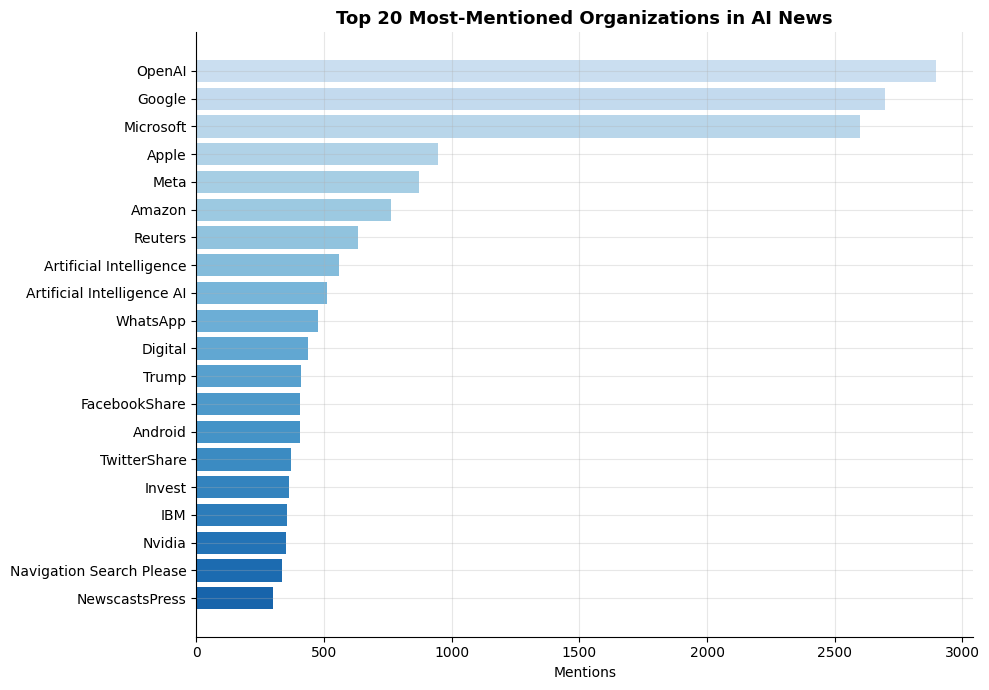

In [12]:
# ── figure: top 20 organizations ─────────────────────────────────────────────
top20_orgs = top_orgs.head(20).sort_values("mentions")

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.Blues_r([i / 20 * 0.6 + 0.2 for i in range(20)])
ax.barh(top20_orgs["organization"], top20_orgs["mentions"], color=colors, edgecolor="none")
ax.set_xlabel("Mentions")
ax.set_title("Top 20 Most-Mentioned Organizations in AI News", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/top_entities.png", dpi=300, bbox_inches="tight")
plt.show()

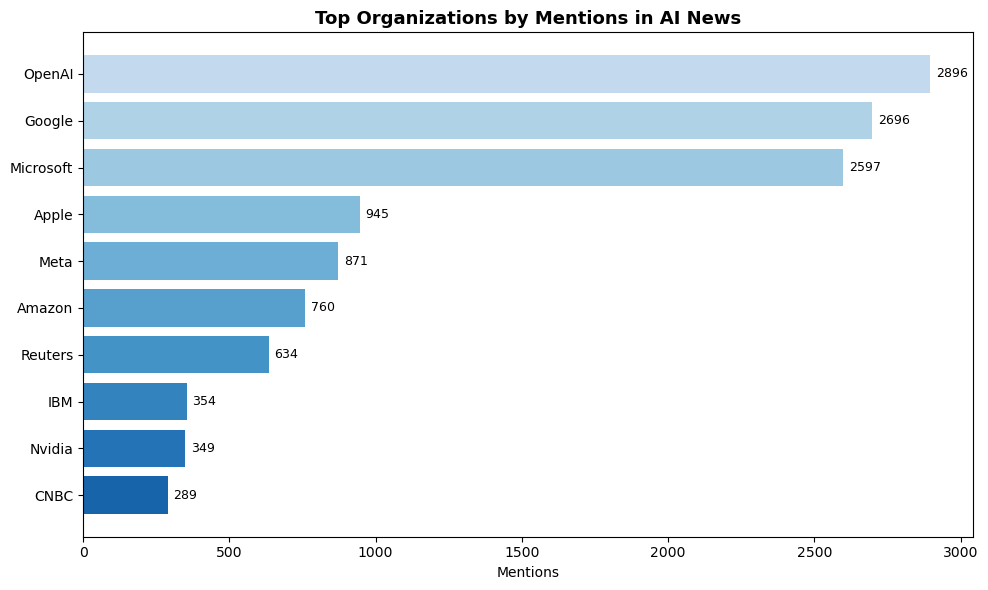

Saved figures/top_entities_clean.png


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

top_orgs = pd.read_csv("outputs/top_entities.csv")

REAL_COMPANIES = [
    "OpenAI", "Google", "Microsoft", "Apple", "Meta", "Amazon",
    "Reuters", "IBM", "Nvidia", "Samsung", "Intel", "Tesla",
    "Anthropic", "Adobe", "CNBC", "Baidu", "Alibaba", "Congress",
    "NYSE", "Goldman Sachs", "JPMorgan", "Qualcomm", "ARM"
]

top_real = (
    top_orgs[top_orgs["organization"].isin(REAL_COMPANIES)]
    .sort_values("mentions", ascending=False)
    .head(10)
    .sort_values("mentions")
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Blues_r([i / len(top_real) * 0.6 + 0.2 for i in range(len(top_real))])
ax.barh(top_real["organization"], top_real["mentions"], color=colors, edgecolor="none")
ax.set_xlabel("Mentions")
ax.set_title("Top Organizations by Mentions in AI News", fontsize=13, fontweight="bold")
for i, (_, row) in enumerate(top_real.iterrows()):
    ax.text(row["mentions"] + 20, i, str(row["mentions"]), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/top_entities_clean.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved figures/top_entities_clean.png")

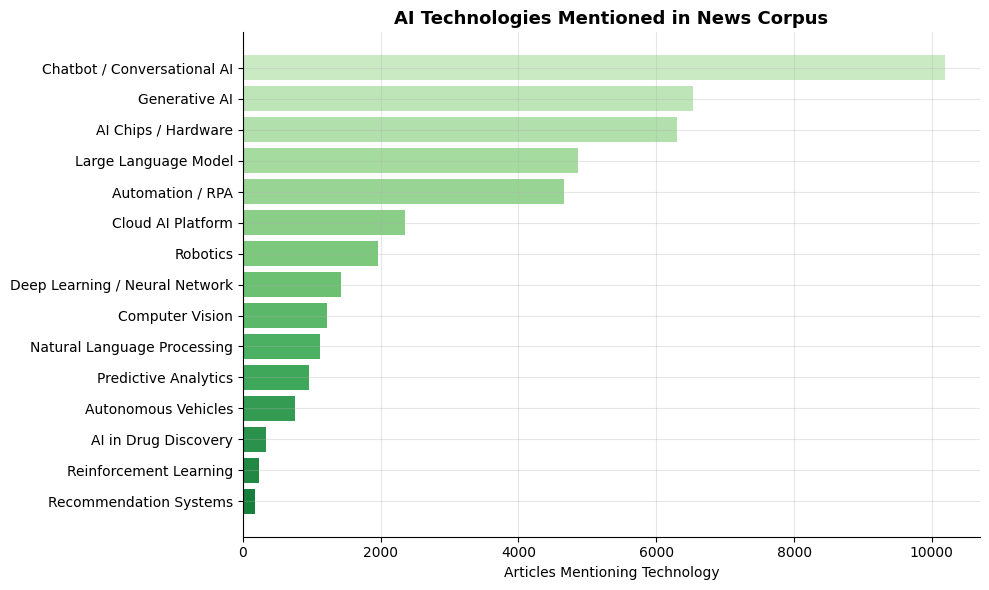

In [13]:
# ── figure: technology mention frequency ─────────────────────────────────────
techs_sorted = top_techs.sort_values("article_count")

fig, ax = plt.subplots(figsize=(10, 6))
colors2 = plt.cm.Greens_r([i / len(techs_sorted) * 0.6 + 0.2 for i in range(len(techs_sorted))])
ax.barh(techs_sorted["technology"], techs_sorted["article_count"], color=colors2, edgecolor="none")
ax.set_xlabel("Articles Mentioning Technology")
ax.set_title("AI Technologies Mentioned in News Corpus", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/top_technologies.png", dpi=300, bbox_inches="tight")
plt.show()

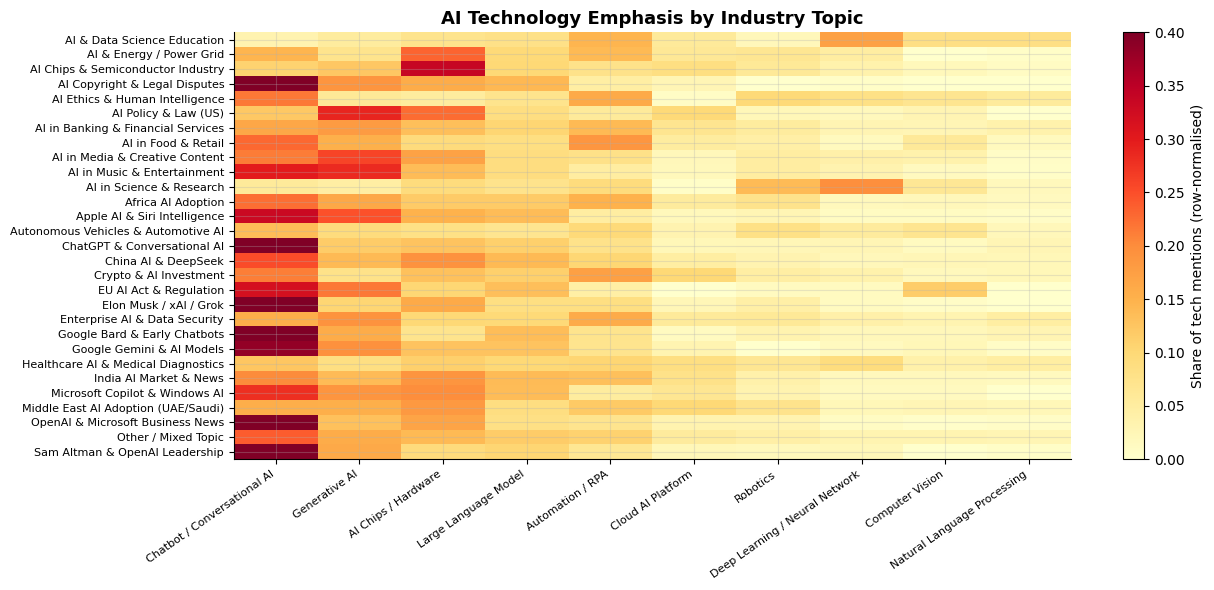

In [14]:
# ── figure: technology heatmap by industry ────────────────────────────────────
import numpy as np

pivot = (
    tech_by_topic
    .pivot(index="topic_label", columns="entity", values="count")
    .fillna(0)
)
# Normalise rows to show relative emphasis within each topic
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

# Keep top 10 techs by total count
top10_tech_cols = top_techs["technology"].head(10).tolist()
pivot_plot = pivot_norm[[c for c in top10_tech_cols if c in pivot_norm.columns]]

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(pivot_plot.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=0.4)
ax.set_xticks(range(pivot_plot.shape[1]))
ax.set_xticklabels(pivot_plot.columns, rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(pivot_plot.shape[0]))
ax.set_yticklabels([lbl[:40] for lbl in pivot_plot.index], fontsize=8)
plt.colorbar(im, ax=ax, label="Share of tech mentions (row-normalised)")
ax.set_title("AI Technology Emphasis by Industry Topic", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/tech_heatmap_by_topic.png", dpi=300, bbox_inches="tight")
plt.show()